Experimento DreamerV2 - Ms. Pac-Man
Total pasos de entrenamiento: 201688
Total episodios de entrenamiento: 104.0
Recompensa media en entrenamiento: 253.75
Episodios de evaluación: 6.0
Recompensa media en evaluación: 432.00
Mejor recompensa en evaluación: 1170.00


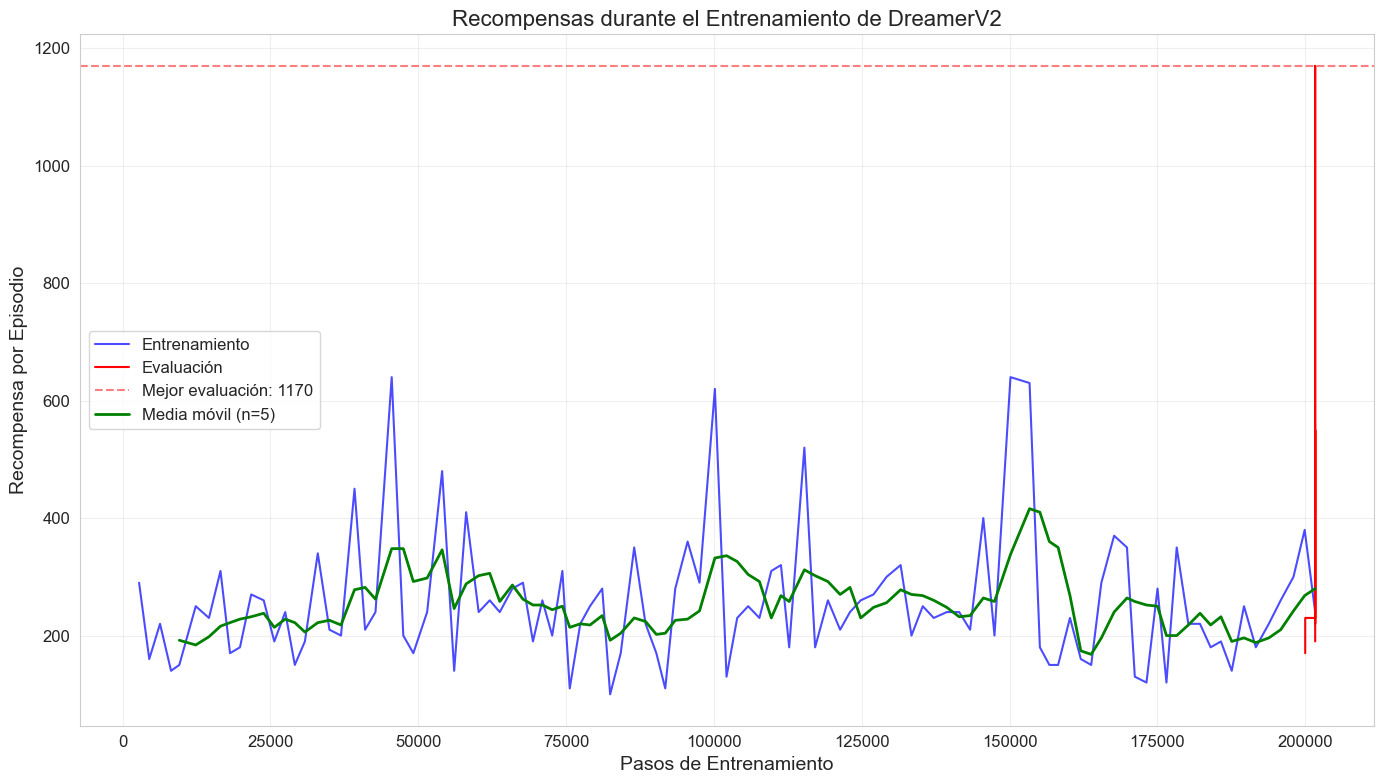


Métricas disponibles del modelo:
1. actor_ent	2. actor_ent_scale	3. actor_grad_norm	4. actor_loss	
5. actor_loss_scale	6. critic_grad_norm	7. critic_loss	8. critic_loss_scale	
9. critic_slow	10. critic_target	11. discount_loss	12. image_loss	
13. kl_loss	14. model_kl	15. model_loss	16. model_loss_scale	
17. post_ent	18. prior_ent	19. reward_loss	20. reward_mean	
21. reward_normed_mean	22. reward_normed_std	23. reward_std	



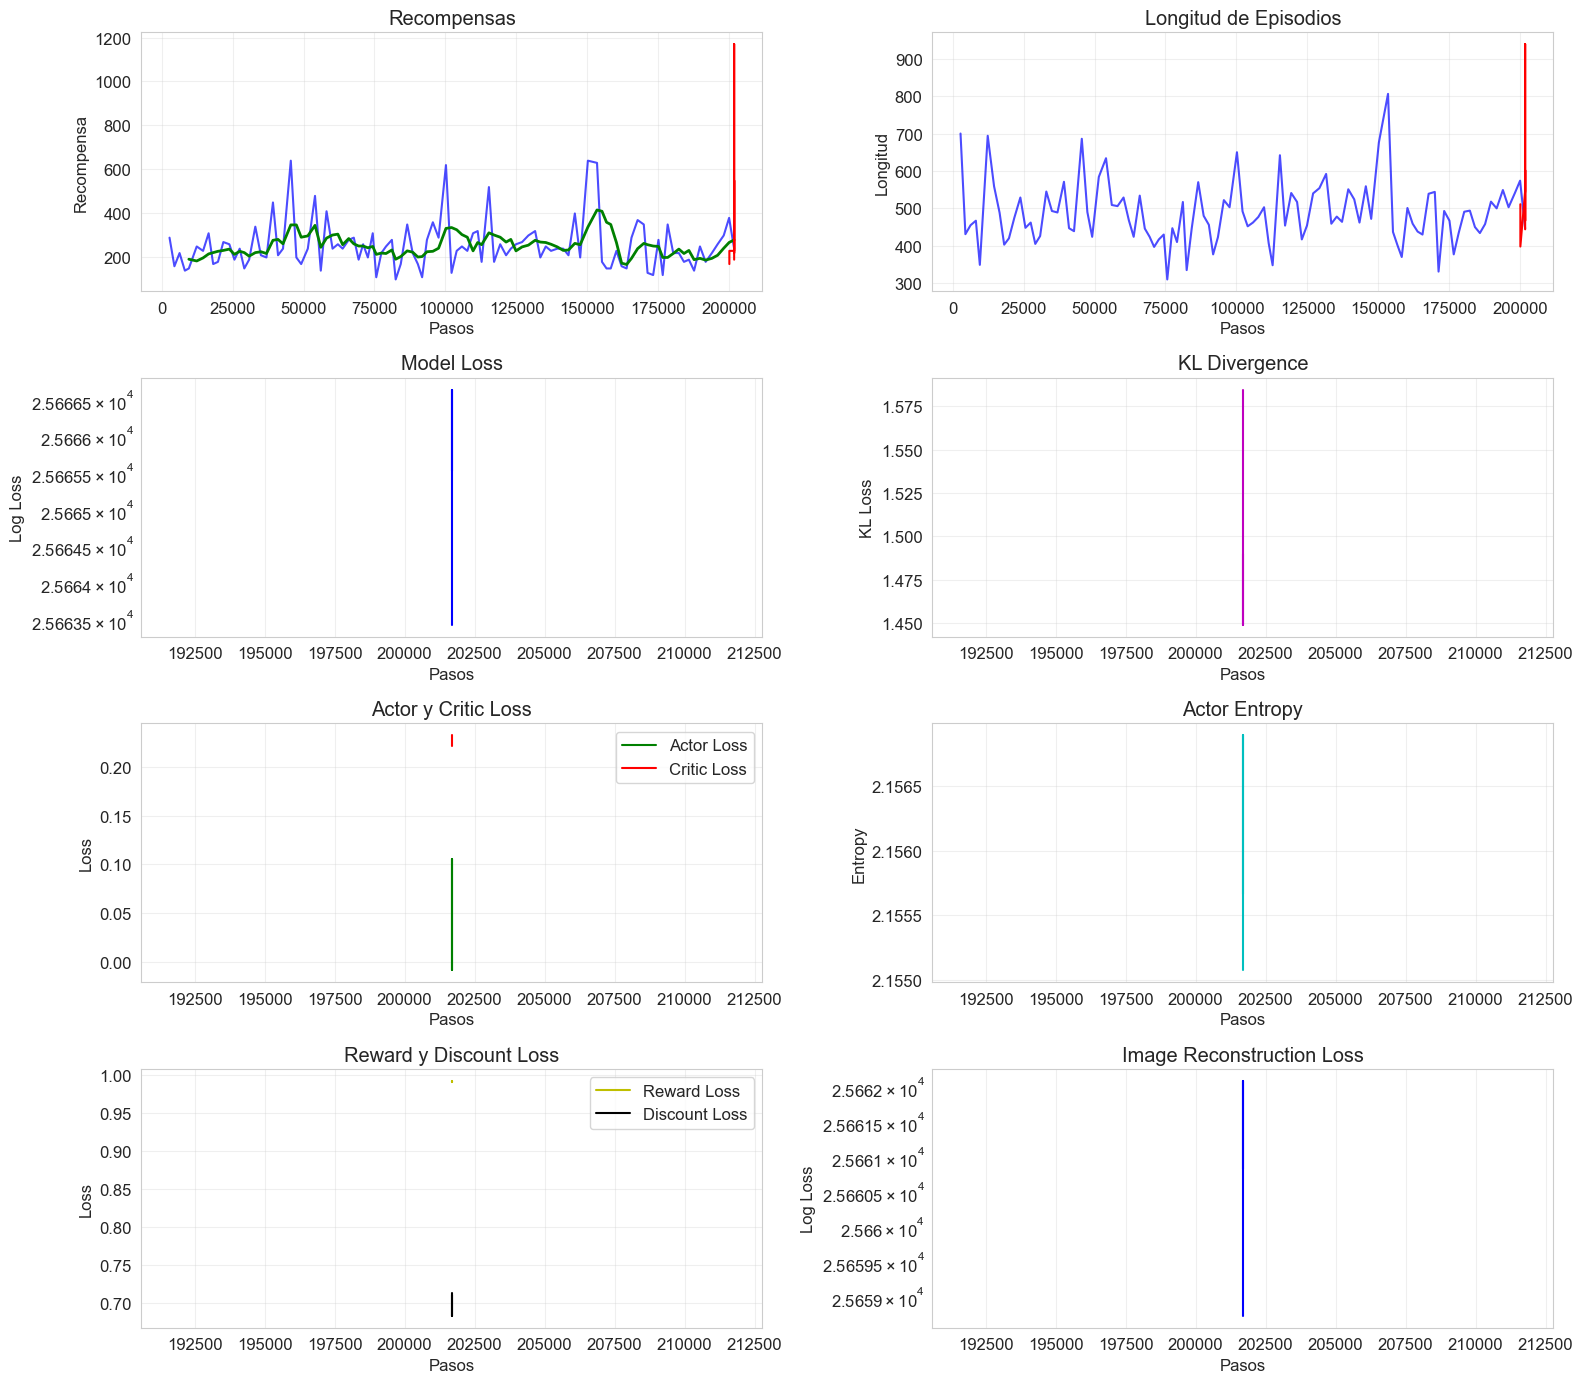

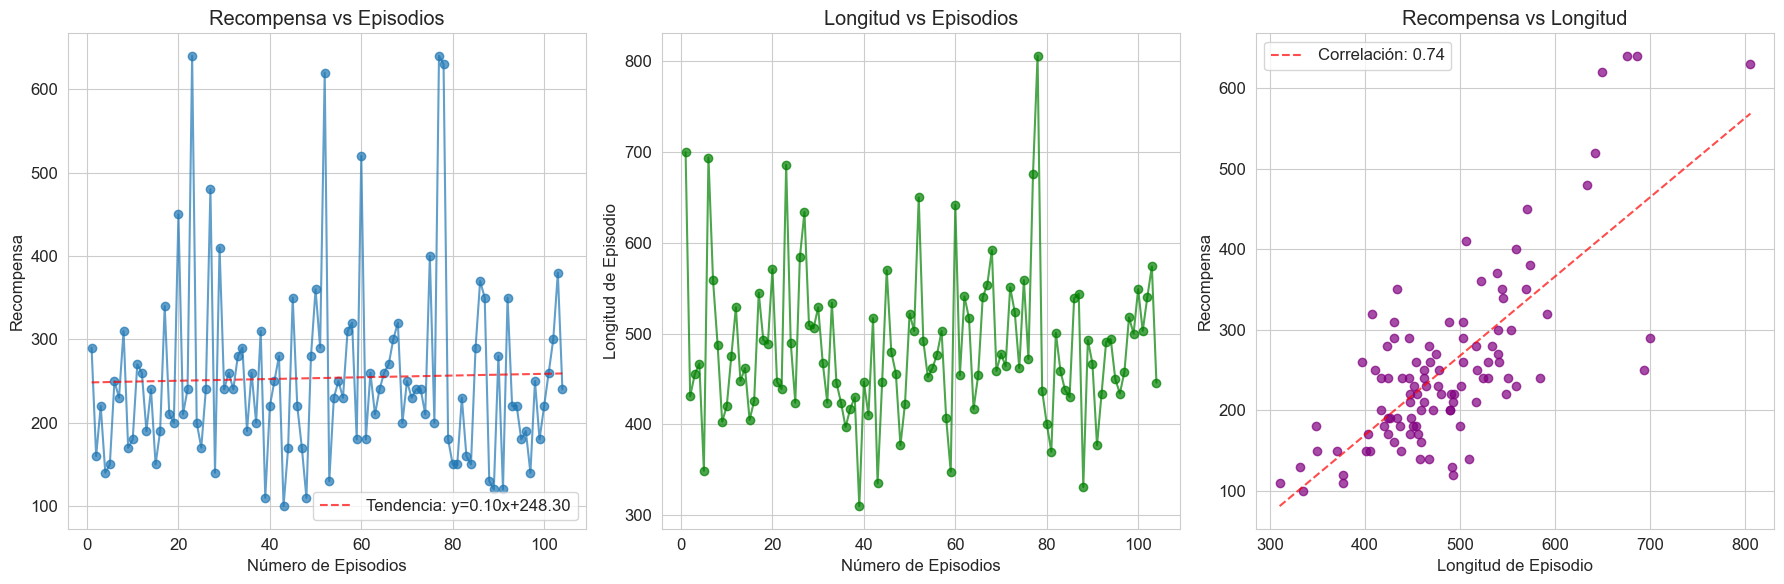

c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


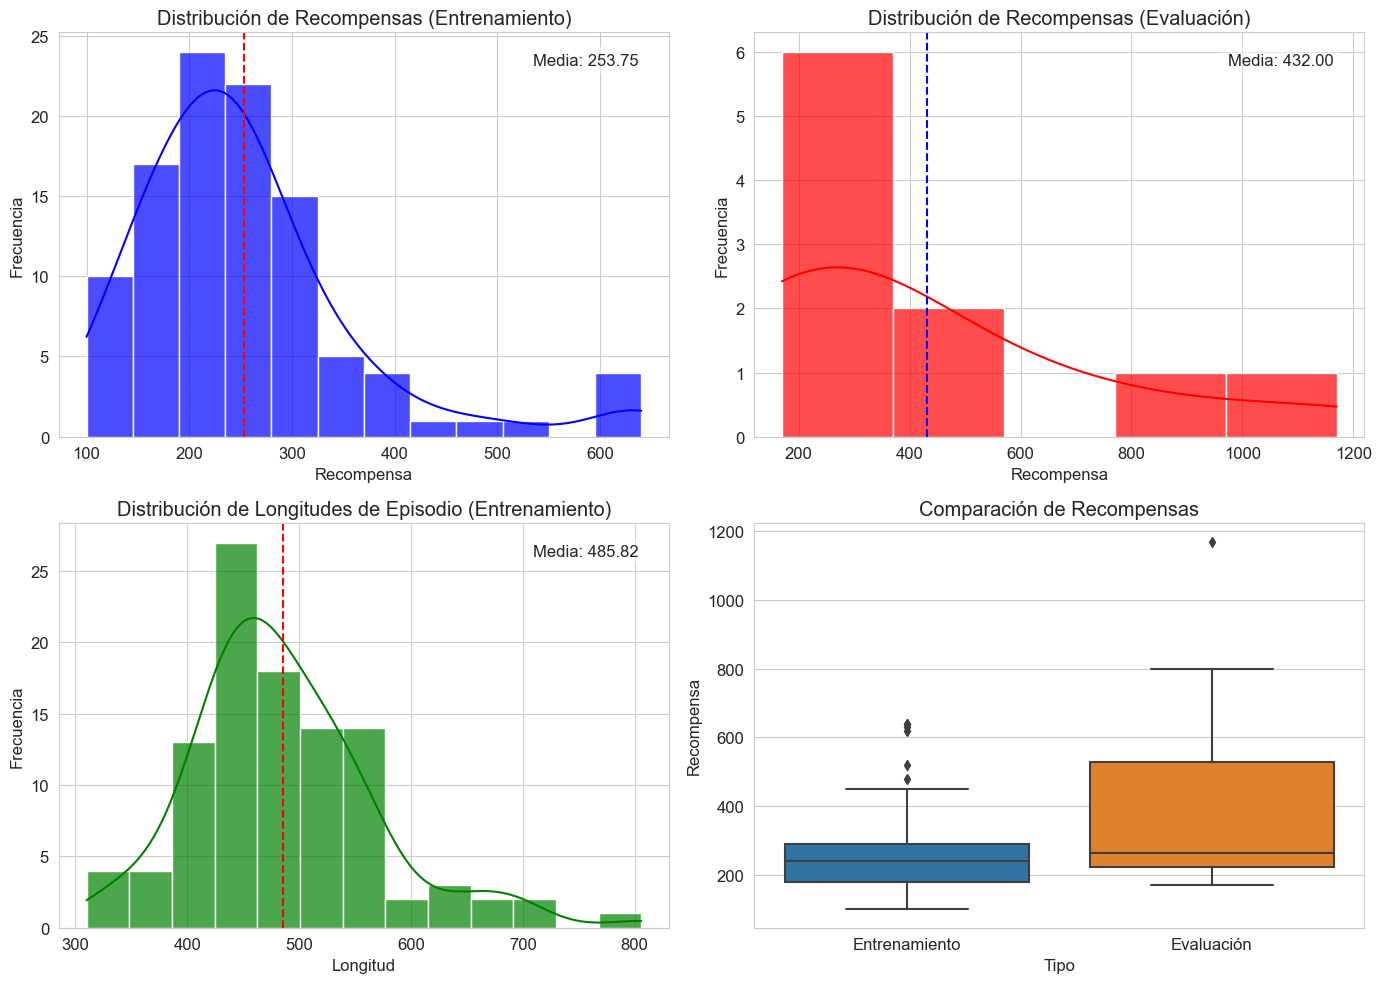

,Paso,Recompensa,Longitud,Episodio
0,45520,640.000000,686.000000,23.000000
1,150160,640.000000,676.000000,77.000000
2,153384,630.000000,806.000000,78.000000
3,100172,620.000000,650.000000,52.000000
4,115304,520.000000,642.000000,60.000000
5,54048,480.000000,634.000000,27.000000
6,39232,450.000000,571.000000,20.000000
7,58108,410.000000,506.000000,29.000000
8,145568,400.000000,559.000000,75.000000
9,199908,380.000000,574.000000,103.000000


,Paso,Recompensa,Longitud,Episodio
0,201684,1170.000000,828.000000,3.000000
1,201684,800.000000,939.000000,3.000000
2,201684,550.000000,602.000000,5.000000
3,201684,460.000000,647.000000,3.000000
4,201684,300.000000,458.000000,6.000000
5,200000,230.000000,398.000000,1.000000
6,201684,230.000000,546.000000,3.000000
7,201684,220.000000,467.000000,4.000000
8,201688,190.000000,444.000000,2.000000
9,200000,170.000000,511.000000,0.000000


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from IPython.display import HTML, display
import ipywidgets as widgets

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Función para cargar los datos del JSONL
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return data

# Cargar datos del archivo metrics.jsonl
current_dir = os.path.dirname(os.path.abspath('__file__'))
metrics_path = os.path.join(current_dir, 'metrics.jsonl')
data = load_jsonl(metrics_path)

# Convertir a DataFrame para facilitar el análisis
df = pd.DataFrame(data)

# Separar datos de entrenamiento y evaluación
train_df = df[df['train_return'].notna()].copy()
eval_df = df[df['eval_return'].notna()].copy()

# Organizar por pasos de entrenamiento
train_df = train_df.sort_values('step')
eval_df = eval_df.sort_values('step')

# Mostrar información general del experimento
print(f"Experimento DreamerV2 - Ms. Pac-Man")
print(f"Total pasos de entrenamiento: {train_df['step'].max()}")
print(f"Total episodios de entrenamiento: {train_df['train_total_episodes'].max()}")
print(f"Recompensa media en entrenamiento: {train_df['train_return'].mean():.2f}")
if not eval_df.empty:
    print(f"Episodios de evaluación: {eval_df['eval_total_episodes'].max()}")
    print(f"Recompensa media en evaluación: {eval_df['eval_return'].mean():.2f}")
    print(f"Mejor recompensa en evaluación: {eval_df['eval_return'].max():.2f}")

# Visualización 1: Recompensas a lo largo del entrenamiento
fig, ax = plt.subplots(figsize=(14, 8))

# Graficar recompensas de entrenamiento
ax.plot(train_df['step'], train_df['train_return'], 'b-', alpha=0.7, label='Entrenamiento')

# Graficar recompensas de evaluación si existen
if not eval_df.empty:
    ax.plot(eval_df['step'], eval_df['eval_return'], 'r-', label='Evaluación')
    
    # Añadir línea de la mejor recompensa de evaluación
    best_reward = eval_df['eval_return'].max()
    ax.axhline(y=best_reward, color='r', linestyle='--', alpha=0.5, 
               label=f'Mejor evaluación: {best_reward:.0f}')

# Media móvil para suavizar las recompensas de entrenamiento
window_size = 5
if len(train_df) >= window_size:
    train_df['smooth_return'] = train_df['train_return'].rolling(window=window_size).mean()
    ax.plot(train_df['step'], train_df['smooth_return'], 'g-', linewidth=2, 
            label=f'Media móvil (n={window_size})')

ax.set_title('Recompensas durante el Entrenamiento de DreamerV2', fontsize=16)
ax.set_xlabel('Pasos de Entrenamiento', fontsize=14)
ax.set_ylabel('Recompensa por Episodio', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 2: Dashboard completo de métricas
# Verificar las columnas disponibles para métricas del modelo
model_metrics = [col for col in df.columns if any(x in col for x in ['loss', 'kl', 'ent', 'reward_', 'discount_', 'actor_', 'critic_'])]
print("\nMétricas disponibles del modelo:")
for i, metric in enumerate(sorted(model_metrics)):
    print(f"{i+1}. {metric}", end="\t")
    if (i+1) % 4 == 0:
        print()  # Nueva línea cada 4 métricas
print("\n")

# Crear un dashboard completo
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(4, 2, figure=fig)

# 1. Recompensas
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_df['step'], train_df['train_return'], 'b-', alpha=0.7)
if 'smooth_return' in train_df:
    ax1.plot(train_df['step'], train_df['smooth_return'], 'g-', linewidth=2)
if not eval_df.empty:
    ax1.plot(eval_df['step'], eval_df['eval_return'], 'r-')
ax1.set_title('Recompensas')
ax1.set_xlabel('Pasos')
ax1.set_ylabel('Recompensa')
ax1.grid(True, alpha=0.3)

# 2. Longitudes de episodio
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(train_df['step'], train_df['train_length'], 'b-', alpha=0.7)
if not eval_df.empty:
    ax2.plot(eval_df['step'], eval_df['eval_length'], 'r-')
ax2.set_title('Longitud de Episodios')
ax2.set_xlabel('Pasos')
ax2.set_ylabel('Longitud')
ax2.grid(True, alpha=0.3)

# 3. Pérdidas del modelo (si existen)
if 'model_loss' in df.columns:
    model_df = df[df['model_loss'].notna()].sort_values('step')
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.semilogy(model_df['step'], model_df['model_loss'], 'b-')
    ax3.set_title('Model Loss')
    ax3.set_xlabel('Pasos')
    ax3.set_ylabel('Log Loss')
    ax3.grid(True, alpha=0.3)

# 4. KL Divergence (si existe)
if 'kl_loss' in df.columns:
    kl_df = df[df['kl_loss'].notna()].sort_values('step')
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(kl_df['step'], kl_df['kl_loss'], 'm-')
    ax4.set_title('KL Divergence')
    ax4.set_xlabel('Pasos')
    ax4.set_ylabel('KL Loss')
    ax4.grid(True, alpha=0.3)

# 5. Actor y Critic Loss (si existen)
if 'actor_loss' in df.columns and 'critic_loss' in df.columns:
    ac_df = df[(df['actor_loss'].notna()) & (df['critic_loss'].notna())].sort_values('step')
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.plot(ac_df['step'], ac_df['actor_loss'], 'g-', label='Actor Loss')
    ax5.plot(ac_df['step'], ac_df['critic_loss'], 'r-', label='Critic Loss')
    ax5.set_title('Actor y Critic Loss')
    ax5.set_xlabel('Pasos')
    ax5.set_ylabel('Loss')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 6. Actor Entropy (si existe)
if 'actor_ent' in df.columns:
    ent_df = df[df['actor_ent'].notna()].sort_values('step')
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(ent_df['step'], ent_df['actor_ent'], 'c-')
    ax6.set_title('Actor Entropy')
    ax6.set_xlabel('Pasos')
    ax6.set_ylabel('Entropy')
    ax6.grid(True, alpha=0.3)

# 7. Reward y Discount Loss (si existen)
if 'reward_loss' in df.columns and 'discount_loss' in df.columns:
    rd_df = df[(df['reward_loss'].notna()) & (df['discount_loss'].notna())].sort_values('step')
    ax7 = fig.add_subplot(gs[3, 0])
    ax7.plot(rd_df['step'], rd_df['reward_loss'], 'y-', label='Reward Loss')
    ax7.plot(rd_df['step'], rd_df['discount_loss'], 'k-', label='Discount Loss')
    ax7.set_title('Reward y Discount Loss')
    ax7.set_xlabel('Pasos')
    ax7.set_ylabel('Loss')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

# 8. Image Loss (si existe)
if 'image_loss' in df.columns:
    img_df = df[df['image_loss'].notna()].sort_values('step')
    ax8 = fig.add_subplot(gs[3, 1])
    ax8.semilogy(img_df['step'], img_df['image_loss'], 'b-')
    ax8.set_title('Image Reconstruction Loss')
    ax8.set_xlabel('Pasos')
    ax8.set_ylabel('Log Loss')
    ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualización 3: Widget interactivo para explorar métricas específicas
available_metrics = sorted([col for col in df.columns if col != 'step' and not df[col].isna().all()])

def plot_selected_metric(metric):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Filtrar valores no nulos
    metric_df = df[df[metric].notna()].sort_values('step')
    
    if len(metric_df) > 0:
        # Determinar si usar escala logarítmica
        use_log = 'loss' in metric and metric_df[metric].max() / max(1e-5, metric_df[metric].min()) > 100
        
        if use_log:
            ax.semilogy(metric_df['step'], metric_df[metric], 'b-')
        else:
            ax.plot(metric_df['step'], metric_df[metric], 'b-')
            
        # Media móvil si hay suficientes puntos
        if len(metric_df) > 5:
            metric_df['smooth'] = metric_df[metric].rolling(window=5).mean()
            ax.plot(metric_df['step'], metric_df['smooth'], 'r-', linewidth=2, label='Media móvil (n=5)')
            ax.legend()
        
        ax.set_title(f'Métrica: {metric}')
        ax.set_xlabel('Pasos de Entrenamiento')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        
        # Estadísticas básicas
        mean_val = metric_df[metric].mean()
        std_val = metric_df[metric].std()
        min_val = metric_df[metric].min()
        max_val = metric_df[metric].max()
        
        # Mostrar estadísticas en el gráfico
        stats_text = f"Media: {mean_val:.4f}\nDesv. Est.: {std_val:.4f}\nMin: {min_val:.4f}\nMax: {max_val:.4f}"
        ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay datos disponibles para la métrica {metric}")

# Crear widget para selección de métrica
metric_dropdown = widgets.Dropdown(
    options=available_metrics,
    value=available_metrics[0] if available_metrics else None,
    description='Métrica:',
    style={'description_width': 'initial'},
    layout={'width': '50%'}
)

# Mostrar widget
output = widgets.interactive_output(plot_selected_metric, {'metric': metric_dropdown})
display(widgets.VBox([metric_dropdown, output]))

# Visualización 4: Progreso de entrenamiento con estadísticas
# Crear gráfico de progresión de entrenamiento con líneas de tendencia
if len(train_df) > 0:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Recompensa vs Episodios
    axs[0].plot(train_df['train_total_episodes'], train_df['train_return'], 'o-', alpha=0.7)
    axs[0].set_title('Recompensa vs Episodios')
    axs[0].set_xlabel('Número de Episodios')
    axs[0].set_ylabel('Recompensa')
    
    # Línea de tendencia
    if len(train_df) > 2:
        z = np.polyfit(train_df['train_total_episodes'], train_df['train_return'], 1)
        p = np.poly1d(z)
        axs[0].plot(train_df['train_total_episodes'], p(train_df['train_total_episodes']), 
                   "r--", alpha=0.7, label=f'Tendencia: y={z[0]:.2f}x+{z[1]:.2f}')
        axs[0].legend()
    
    # 2. Longitud vs Episodios
    axs[1].plot(train_df['train_total_episodes'], train_df['train_length'], 'o-', alpha=0.7, color='green')
    axs[1].set_title('Longitud vs Episodios')
    axs[1].set_xlabel('Número de Episodios')
    axs[1].set_ylabel('Longitud de Episodio')
    
    # 3. Recompensa vs Longitud (scatter)
    axs[2].scatter(train_df['train_length'], train_df['train_return'], alpha=0.7, color='purple')
    axs[2].set_title('Recompensa vs Longitud')
    axs[2].set_xlabel('Longitud de Episodio')
    axs[2].set_ylabel('Recompensa')
    
    # Línea de regresión
    if len(train_df) > 2:
        z = np.polyfit(train_df['train_length'], train_df['train_return'], 1)
        p = np.poly1d(z)
        axs[2].plot(sorted(train_df['train_length']), p(sorted(train_df['train_length'])), 
                   "r--", alpha=0.7, label=f'Correlación: {np.corrcoef(train_df["train_length"], train_df["train_return"])[0,1]:.2f}')
        axs[2].legend()
    
    plt.tight_layout()
    plt.show()

# Visualización 5: Histogramas y distribuciones
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de recompensas de entrenamiento
sns.histplot(train_df['train_return'], kde=True, ax=axs[0, 0], color='blue', alpha=0.7)
axs[0, 0].axvline(train_df['train_return'].mean(), color='r', linestyle='--')
axs[0, 0].set_title('Distribución de Recompensas (Entrenamiento)')
axs[0, 0].set_xlabel('Recompensa')
axs[0, 0].set_ylabel('Frecuencia')
axs[0, 0].text(0.95, 0.95, f'Media: {train_df["train_return"].mean():.2f}', 
              transform=axs[0, 0].transAxes, ha='right', va='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 2. Distribución de recompensas de evaluación (si existen)
if not eval_df.empty:
    sns.histplot(eval_df['eval_return'], kde=True, ax=axs[0, 1], color='red', alpha=0.7)
    axs[0, 1].axvline(eval_df['eval_return'].mean(), color='blue', linestyle='--')
    axs[0, 1].set_title('Distribución de Recompensas (Evaluación)')
    axs[0, 1].set_xlabel('Recompensa')
    axs[0, 1].set_ylabel('Frecuencia')
    axs[0, 1].text(0.95, 0.95, f'Media: {eval_df["eval_return"].mean():.2f}', 
                  transform=axs[0, 1].transAxes, ha='right', va='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
else:
    axs[0, 1].set_title('No hay datos de evaluación disponibles')
    axs[0, 1].axis('off')

# 3. Distribución de longitudes de episodio (entrenamiento)
sns.histplot(train_df['train_length'], kde=True, ax=axs[1, 0], color='green', alpha=0.7)
axs[1, 0].axvline(train_df['train_length'].mean(), color='r', linestyle='--')
axs[1, 0].set_title('Distribución de Longitudes de Episodio (Entrenamiento)')
axs[1, 0].set_xlabel('Longitud')
axs[1, 0].set_ylabel('Frecuencia')
axs[1, 0].text(0.95, 0.95, f'Media: {train_df["train_length"].mean():.2f}', 
              transform=axs[1, 0].transAxes, ha='right', va='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 4. Boxplot comparativo (si hay datos de evaluación)
if not eval_df.empty:
    # Preparar datos para boxplot - crear un dataframe con formato largo
    box_data_train = pd.DataFrame({
        'Recompensa': train_df['train_return'],
        'Tipo': 'Entrenamiento'
    })
    box_data_eval = pd.DataFrame({
        'Recompensa': eval_df['eval_return'],
        'Tipo': 'Evaluación'
    })
    box_data_df = pd.concat([box_data_train, box_data_eval])
    # Usar el formato correcto para seaborn
    sns.boxplot(x='Tipo', y='Recompensa', data=box_data_df, ax=axs[1, 1])
    axs[1, 1].set_title('Comparación de Recompensas')
    axs[1, 1].set_ylabel('Recompensa')
else:
    # Scatterplot de recompensa vs pasos en lugar del boxplot
    sns.regplot(x='step', y='train_return', data=train_df, ax=axs[1, 1], scatter_kws={'alpha':0.6})
    axs[1, 1].set_title('Tendencia de Recompensas')
    axs[1, 1].set_xlabel('Pasos')
    axs[1, 1].set_ylabel('Recompensa')

plt.tight_layout()
plt.show()

# Visualización 6: Tabla resumen de las mejores recompensas
if len(train_df) > 0:
    # Ordenar por recompensa
    best_train = train_df.sort_values('train_return', ascending=False).head(10)
    best_train_styled = best_train[['step', 'train_return', 'train_length', 'train_total_episodes']].reset_index(drop=True)
    best_train_styled.columns = ['Paso', 'Recompensa', 'Longitud', 'Episodio']
    
    display(HTML("<h3>Top 10 Mejores Episodios de Entrenamiento</h3>"))
    display(best_train_styled.style.highlight_max(color='lightgreen').highlight_min(color='lightpink'))
    
    if not eval_df.empty:
        best_eval = eval_df.sort_values('eval_return', ascending=False).head(10)
        best_eval_styled = best_eval[['step', 'eval_return', 'eval_length', 'eval_total_episodes']].reset_index(drop=True)
        best_eval_styled.columns = ['Paso', 'Recompensa', 'Longitud', 'Episodio']
        
        display(HTML("<h3>Top 10 Mejores Episodios de Evaluación</h3>"))
        display(best_eval_styled.style.highlight_max(color='lightgreen').highlight_min(color='lightpink'))

# Visualización 7: Estadísticas finales y resumen
total_steps = train_df